In [2]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [131]:
import pandas as pd
import numpy as np
import h5py

In [ ]:
f1 = h5py.File('2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'r')
batch1 = f1['batch']

f2 = h5py.File('2017-06-30_batchdata_updated_struct_errorcorrect.mat', 'r')
batch2 = f2['batch']

f3 = h5py.File('2018-04-12_batchdata_updated_struct_errorcorrect.mat', 'r')
batch3 = f3['batch']


In [5]:
print(batch1['summary'].shape[0])
print(batch2['summary'].shape[0])
print(batch3['summary'].shape[0])

46
48
46


In [6]:
list(f1.keys())

['#refs#', '#subsystem#', 'batch', 'batch_date']

In [7]:
list(batch1.keys())

['Vdlin',
 'barcode',
 'channel_id',
 'cycle_life',
 'cycles',
 'policy',
 'policy_readable',
 'summary']

In [8]:
c = f1[batch1['cycles'][0, 0]]
print("Cycle keys:", list(c.keys()))

Cycle keys: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']


In [9]:
v = f1[c['V'][0, 0]][()].ravel()
print(v.shape, v.min(), v.max())

(2,) 0 0


In [10]:
cycle_idx = 1   # choose the cycle number you want

# Load raw arrays
V  = f1[c['V'][cycle_idx, 0]][()].ravel()
I  = f1[c['I'][cycle_idx, 0]][()].ravel()
T  = f1[c['T'][cycle_idx, 0]][()].ravel()
Qd = f1[c['Qd'][cycle_idx, 0]][()].ravel()
Qc = f1[c['Qc'][cycle_idx, 0]][()].ravel()
t  = f1[c['t'][cycle_idx, 0]][()].ravel()

# Build a tabular DataFrame
df_cycle = pd.DataFrame({
    "time_s": t,
    "voltage_V": V,
    "current_A": I,
    "temperature_C": T,
    "Q_discharge_Ah": Qd,
    "Q_charge_Ah": Qc
})

df_cycle


,time_s,voltage_V,current_A,temperature_C,Q_discharge_Ah,Q_charge_Ah
0,0.000000,2.026416,0.000000,31.632496,0.000000,0.000000
1,0.002417,2.039388,0.215908,31.632496,0.000000,0.000001
2,0.002912,2.051660,0.359831,31.632496,0.000000,0.000001
3,0.003212,2.063070,0.467846,31.632496,0.000000,0.000001
4,0.003498,2.076204,0.575877,31.632496,0.000000,0.000001
...,...,...,...,...,...,...
1082,54.357120,1.999842,-0.034227,31.712118,1.070688,1.071042
1083,54.358155,2.002296,-0.034227,31.712118,1.070689,1.071042
1084,54.365115,2.012406,-0.034227,31.712118,1.070689,1.071042
1085,54.372673,2.022461,-0.034227,31.712118,1.070689,1.071042


In [11]:
df_cycle[650:675]

,time_s,voltage_V,current_A,temperature_C,Q_discharge_Ah,Q_charge_Ah
650,33.856615,3.599870,0.047934,29.625114,0.000000,1.070603
651,33.939928,3.599814,0.047934,29.612093,0.000000,1.070676
652,34.023288,3.599790,0.047869,29.619164,0.000000,1.070750
653,34.106608,3.599761,0.047898,29.628511,0.000000,1.070823
654,34.189852,3.599794,0.047905,29.609203,0.000000,1.070896
655,34.273242,3.599821,0.047900,29.604231,0.000000,1.070969
656,34.356535,3.599888,0.047893,29.585907,0.000000,1.071042
657,34.356583,3.599879,0.047895,29.585907,0.000000,1.071042
658,34.358435,3.589563,-0.439630,29.585907,0.000000,1.071042
659,34.359667,3.578016,-0.920006,29.585907,0.000000,1.071042


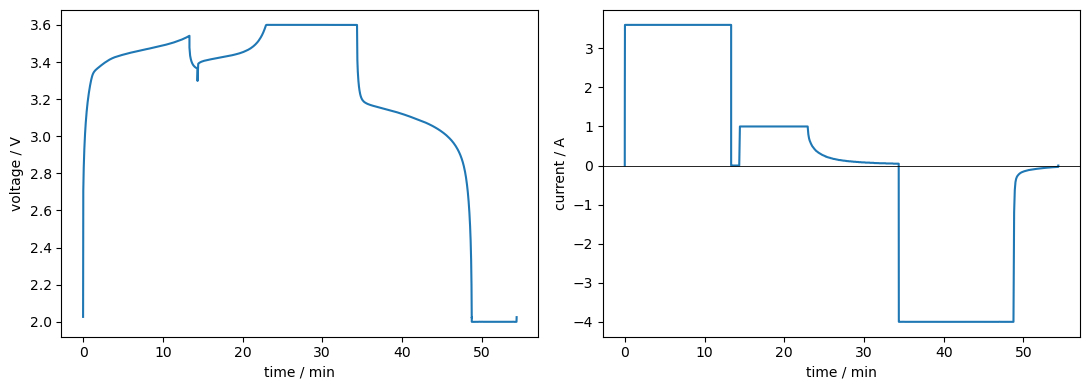

V max: 3.6003742 at row 479 of 1087


In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, V); ax[0].set_ylabel('voltage / V')
ax[1].plot(t, I); ax[1].set_ylabel('current / A'); ax[1].axhline(0, c='k', lw=0.6)
for a in ax: a.set_xlabel('time / min')
plt.tight_layout(); plt.show()

print("V max:", V.max(), "at row", V.argmax(), "of", len(V))

In [13]:
cycle_idx = 1
print("V     :", f1[c['V'][cycle_idx, 0]][()].ravel().shape)
print("Qdlin :", f1[c['Qdlin'][cycle_idx, 0]][()].ravel().shape)
print("Tdlin :", f1[c['Tdlin'][cycle_idx, 0]][()].ravel().shape)
print("dQdV  :", f1[c['discharge_dQdV'][cycle_idx, 0]][()].ravel().shape)
print("Vdlin :", f1[batch1['Vdlin'][0, 0]][()].ravel().shape)

V     : (1087,)
Qdlin : (1000,)
Tdlin : (1000,)
dQdV  : (1000,)
Vdlin : (1000,)


In [14]:
i = 0  # battery index
ref = batch1['summary'][i, 0]     # HDF5 reference
battery_summary = f1[ref]         # battery-level summary struct

list(battery_summary.keys())

['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

In [15]:
i = 0                                    # cell b1c0
s = f1[batch1['summary'][i, 0]]

cyc_df = pd.DataFrame({k: np.asarray(s[k]).ravel() for k in s.keys()})
print(cyc_df.shape)
cyc_df.head(10)

(1189, 8)


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0
5,0.016623,1.073491,1.073576,31.961062,35.711758,29.752932,13.340835,6.0
6,0.016600,1.073922,1.073992,31.900562,35.615650,29.564377,13.340198,7.0
7,0.016577,1.074158,1.074374,31.921668,35.546783,29.628630,13.425442,8.0
8,0.016588,1.074337,1.074492,31.870082,35.539406,29.597345,13.425190,9.0
9,0.016572,1.074353,1.074537,31.841053,35.499729,29.687315,13.425633,10.0


In [16]:
cyc_df.tail(5)

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
1184,0.017084,1.026296,1.026472,32.305923,36.718185,29.846605,13.341380,1185.0
1185,0.017078,1.026559,1.026700,32.307072,36.600224,29.723915,13.425378,1186.0
1186,0.017085,1.026315,1.026499,32.296148,36.750278,29.727167,13.425498,1187.0
1187,0.017072,1.026620,1.026677,32.208778,36.758877,29.654888,13.340972,1188.0
1188,0.017089,1.026054,1.026210,32.200804,36.561554,29.681129,13.425712,1189.0


In [17]:
def scalar(f, ref):
    return np.asarray(f[ref][()]).ravel()[0]

def text(f, ref):
    return f[ref][()].tobytes()[::2].decode('utf-8', errors='replace')
  

In [18]:
def early_value(arr, n=5):
    """Mean of the first n strictly positive entries."""
    good = arr[arr > 0]
    if len(good) == 0:
        return np.nan
    return good[:n].mean()

In [19]:
def batch_table(f, batch, label):
    rows = []
    for i in range(batch['summary'].shape[0]):
        s = f[batch['summary'][i, 0]]
        qd = np.asarray(s['QDischarge']).ravel()
        ir = np.asarray(s['IR']).ravel()
        rows.append({
            'cell_id':     f'{label}c{i}',
            'policy':      text(f, batch['policy_readable'][i, 0]),
            'cycle_life':  scalar(f, batch['cycle_life'][i, 0]),
            'n_cycles':    len(qd),
            'Q_initial':  early_value(qd),
            'Q_last':      qd[-1],
            'IR_initial': early_value(ir),
            'IR_last':     ir[-1],
        })
    return pd.DataFrame(rows).set_index('cell_id')

In [20]:
t1 = batch_table(f1, batch1, 'b1')
t2 = batch_table(f2, batch2, 'b2')
t3 = batch_table(f3, batch3, 'b3')

print(t1.shape, t2.shape, t3.shape)   # expect (46,8) (48,8) (46,8)
t1

(46, 7) (48, 7) (46, 7)


,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last
cell_id,,,,,,,
b1c0,3.6C(80%)-3.6C,1190.0,1189,1.072370,1.026210,0.016687,0.017089
b1c1,3.6C(80%)-3.6C,1179.0,1178,1.077181,1.038225,0.016950,0.017363
b1c2,3.6C(80%)-3.6C,1177.0,1176,1.081847,1.043279,0.016760,0.017273
b1c3,4C(80%)-4C,1226.0,1225,1.081758,0.970921,0.016326,0.017057
b1c4,4C(80%)-4C,1227.0,1226,1.079671,1.021960,0.016734,0.017073
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.077600,0.880536,0.016359,0.019527
b1c6,4.8C(80%)-4.8C,636.0,635,1.078115,0.880057,0.016926,0.020405
b1c7,4.8C(80%)-4.8C,870.0,869,1.095673,0.881106,0.016241,0.019942
b1c8,5.4C(40%)-3.6C,879.0,878,1.091791,0.969025,0.016753,0.017866


In [21]:
t1.policy.dtype

dtype('O')

In [22]:
all_cells = pd.concat(
    [t1.assign(batch=1), t2.assign(batch=2), t3.assign(batch=3)]
)
print(all_cells.shape)                # (140, 9)
all_cells

(140, 8)


,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch
cell_id,,,,,,,,
b1c0,3.6C(80%)-3.6C,1190.0,1189,1.072370,1.026210,0.016687,0.017089,1
b1c1,3.6C(80%)-3.6C,1179.0,1178,1.077181,1.038225,0.016950,0.017363,1
b1c2,3.6C(80%)-3.6C,1177.0,1176,1.081847,1.043279,0.016760,0.017273,1
b1c3,4C(80%)-4C,1226.0,1225,1.081758,0.970921,0.016326,0.017057,1
b1c4,4C(80%)-4C,1227.0,1226,1.079671,1.021960,0.016734,0.017073,1
...,...,...,...,...,...,...,...,...
b3c41,5.6C(36%)-4.3C-newstructure,786.0,785,1.051153,0.880623,0.018507,0.021188,3
b3c42,4.8C(80%)-4.8C-newstructure,1642.0,1641,1.067409,0.880375,0.016358,0.018658,3
b3c43,5C(67%)-4C-newstructure,1046.0,1045,1.070636,0.880607,0.015859,0.019207,3


In [23]:
all_cells.groupby('batch')[['cycle_life', 'n_cycles', 'Q_initial']].describe().T

batch                       1            2            3
cycle_life count    46.000000    48.000000    44.000000
           mean    844.717391   494.708333  1059.659091
           std     184.629198   141.111388   313.869692
           min     534.000000   148.000000   541.000000
           25%     703.250000   461.000000   828.000000
           50%     858.500000   483.000000  1005.500000
           75%     914.250000   503.750000  1155.250000
           max    1227.000000  1061.000000  1935.000000
n_cycles   count    46.000000    48.000000    46.000000
           mean    843.717391   519.166667  1108.847826
           std     184.629198   138.294834   388.341143
           min     533.000000   170.000000   540.000000
           25%     702.250000   486.750000   832.500000
           50%     857.500000   508.000000  1017.500000
           75%     913.250000   533.250000  1156.500000
           max    1226.000000  1060.000000  2237.000000
Q_initial  count    46.000000    48.000000    46.000000
           mean      1.079767     1.065697     1.064400
           std       0.007666     0.020820     0.007194
           min       1.055643     0.971033     1.047037
           25%       1.076478     1.068258     1.061230
           50%       1.080096     1.071420     1.066315
           75%       1.083496     1.075270     1.069232
           max       1.096396     1.083738     1.074698

# Feature extraction 1

In [24]:
i = 0
c = f1[batch1['cycles'][i, 0]]
print(list(c.keys()))
print("cycles stored:", c['Qdlin'].shape[0])

['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
cycles stored: 1189


In [25]:
q10 = f1[c['Qdlin'][9, 0]][()].ravel()    # capacity of the battery i=0 at cycle 10
print(q10.shape, q10[:5], q10[-5:])

(1000,) [-0.00039726 -0.00035584 -0.00031669 -0.00027959 -0.00024434] [1.05869569 1.05871265 1.05872955 1.05874727 1.05876667]


In [26]:
vd = f1[batch1['Vdlin'][i, 0]][()].ravel()
print(vd.shape, vd[:5], vd[-5:])

(1000,) [3.5        3.4984985  3.496997   3.4954955  3.49399399] [2.00600601 2.0045045  2.003003   2.0015015  2.        ]


In [27]:
q100 = f1[c['Qdlin'][99, 0]][()].ravel()    # capacity of the battery at cycle 100
print(q100.shape, q100[:5], q100[-5:])

(1000,) [-0.00034249 -0.00031288 -0.00028317 -0.00025338 -0.0002235 ] [1.05941265 1.05945147 1.05948558 1.05951372 1.0595346 ]


In [28]:
delta_Q = q100 - q10
print(delta_Q.shape, delta_Q.min(), delta_Q.max())

(1000,) -0.008459642934268818 0.0007679306774941441


In [29]:
np.var(delta_Q)

np.float64(9.663600264771342e-06)

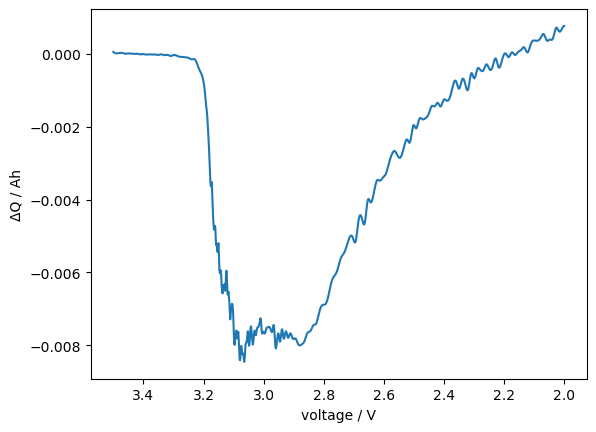

In [30]:
plt.plot(vd, delta_Q)
plt.xlabel('voltage / V'); plt.ylabel('ΔQ / Ah')
plt.gca().invert_xaxis()
plt.show()

Reading the plot

X-axis is voltage, from 3.5 V (start of discharge) on the left to 2.0 V (empty) on the right.

Y-axis is capacity difference, in Ah. Negative means the cell delivered less at cycle 100 than at cycle 10.

Now trace it:

3.5 → 3.2 V: flat at zero. No loss here. Early in the discharge, cycle 100 behaves identically to cycle 10.

3.2 → 3.1 V: falls off a cliff. Drops from 0 to −0.008 over about 0.1 V. Something specific happens right here.

3.1 → 2.8 V: bottom, around −0.008. The loss is at its maximum.

2.8 → 2.0 V: climbs back toward zero. Ends near +0.0008.
# What the shape means

The right-hand end is the key. By 2.0 V the curve has nearly returned to zero — meaning total capacity barely changed between cycle 10 and cycle 100. Which matches your summary table: 1.0745 → 1.0738.

If you'd only looked at total capacity you'd conclude nothing happened.

But something did happen. The cell lost 0.008 Ah in the 3.25–2.8 V window and got it back lower down. Capacity moved rather than disappeared — it now comes out at lower voltages than it used to.

That's degradation you'd never see in the summary numbers. It's the whole reason this feature exists.

# Feature extraction for all the batteries in the 3 batches.

In [31]:
def var_dq_feature(f, batch, label):
    rows = []
    Vdlin = f[batch['Vdlin'][0, 0]][()].ravel()

    for i in range(batch['summary'].shape[0]):
        c = f[batch['cycles'][i, 0]]
        n = c['Qdlin'].shape[0]

        if n < 100:                      # cell died before cycle 100
            rows.append({'cell_id': f'{label}c{i}', 'log_var_dQ': np.nan})
            continue

        q10  = f[c['Qdlin'][9,  0]][()].ravel()
        q100 = f[c['Qdlin'][99, 0]][()].ravel()
        dq = q100 - q10

        rows.append({
            'cell_id':    f'{label}c{i}',
            'log_var_dQ': np.log10(np.var(dq)),
            'min_dQ':     dq.min(),
        })
    return pd.DataFrame(rows).set_index('cell_id')

feature = pd.concat([
    var_dq_feature(f1, batch1, 'b1'),
    var_dq_feature(f2, batch2, 'b2'),
    var_dq_feature(f3, batch3, 'b3'),
])
print(feature.shape)
feature.head()

(140, 2)


,log_var_dQ,min_dQ
cell_id,,
b1c0,-5.014861,-0.008460
b1c1,-5.013960,-0.011004
b1c2,-4.737000,-0.017216
b1c3,-4.442613,-0.018961
b1c4,-4.647744,-0.013958


In [32]:
df = all_cells.join(feature)
df['log_life'] = np.log10(df.cycle_life) #The feature is already logged. Comparing a logged feature to an unlogged cycle gives a curved relationship. Logging both makes it straight.
df.head()

,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch,log_var_dQ,min_dQ,log_life
cell_id,,,,,,,,,,,
b1c0,3.6C(80%)-3.6C,1190.0,1189,1.072370,1.026210,0.016687,0.017089,1,-5.014861,-0.008460,3.075547
b1c1,3.6C(80%)-3.6C,1179.0,1178,1.077181,1.038225,0.016950,0.017363,1,-5.013960,-0.011004,3.071514
b1c2,3.6C(80%)-3.6C,1177.0,1176,1.081847,1.043279,0.016760,0.017273,1,-4.737000,-0.017216,3.070776
b1c3,4C(80%)-4C,1226.0,1225,1.081758,0.970921,0.016326,0.017057,1,-4.442613,-0.018961,3.088490
b1c4,4C(80%)-4C,1227.0,1226,1.079671,1.021960,0.016734,0.017073,1,-4.647744,-0.013958,3.088845


r = -0.857  r² = 0.735


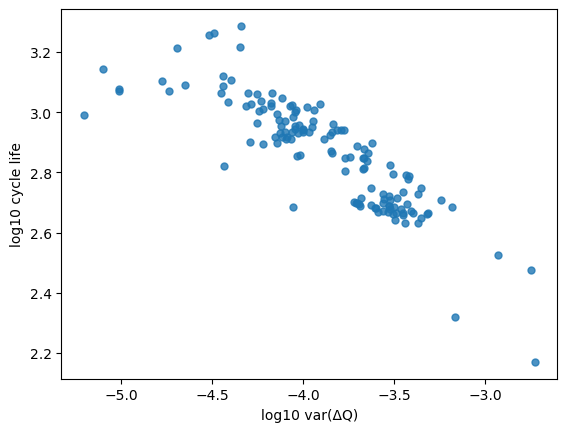

In [33]:
r = df[['log_var_dQ', 'log_life']].dropna().corr().iloc[0, 1]
print("r =", round(r, 3), " r² =", round(r**2, 3))

plt.scatter(df.log_var_dQ, df.log_life, s=25, alpha=0.8)
plt.xlabel('log10 var(ΔQ)'); plt.ylabel('log10 cycle life')
plt.show()

r = -0.829  r² = 0.687


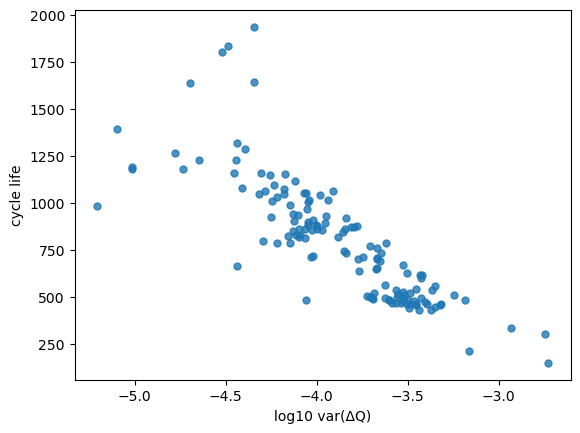

In [34]:
r = df[['log_var_dQ', 'cycle_life']].dropna().corr().iloc[0, 1]
print("r =", round(r, 3), " r² =", round(r**2, 3))

plt.scatter(df.log_var_dQ, df.cycle_life, s=25, alpha=0.8)
plt.xlabel('log10 var(ΔQ)'); plt.ylabel('cycle life')
plt.show()

# Deciding factor: whether to use logged cycle_life or the raw cycle life

In [35]:
d = df[['log_var_dQ', 'cycle_life', 'log_life']].dropna()
bins = pd.cut(d.log_var_dQ, 4)
print(d.groupby(bins)[['cycle_life','log_life']].std())

                  cycle_life  log_life
log_var_dQ                            
(-5.208, -4.586]  191.402157  0.064078
(-4.586, -3.966]  276.080660  0.106848
(-3.966, -3.347]  163.239088  0.108068
(-3.347, -2.727]  136.081318  0.195189


C:\Users\jenim\AppData\Local\Temp\ipykernel_27744\2816417567.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(d.groupby(bins)[['cycle_life','log_life']].std())


# EDA

### Finding cells with unreliable cycle life

`cycle_life` is defined as the cycle at which discharge capacity falls to 0.88 Ah — 80% of the 1.1 Ah nominal capacity. A cell that reached end of life must therefore have a final capacity at or below 0.88 Ah.
This filter looks for the opposite: cells whose **last recorded capacity is still above 0.885 Ah**. Those cells were healthy when recording stopped, so they never died — and their `cycle_life` value cannot be a real death cycle.
(0.885 rather than 0.880 leaves a small margin so measurement noise doesn't flag a cell that genuinely failed.)

**12 cells found.** Confirming they're broken: for every one of them, `cycle_life = n_cycles + 1`. The recorded "lifetime" is just the number of rows in the file, not an observed failure. For `b3c23` and `b3c32` the file carries no value at all — `cycle_life` is NaN.

In [36]:
print(all_cells[all_cells.Q_last > 0.885][['batch','cycle_life','Q_last','n_cycles']])

         batch  cycle_life    Q_last  n_cycles
cell_id                                       
b1c0         1      1190.0  1.026210      1189
b1c1         1      1179.0  1.038225      1178
b1c2         1      1177.0  1.043279      1176
b1c3         1      1226.0  0.970921      1225
b1c4         1      1227.0  1.021960      1226
b1c8         1       879.0  0.969025       878
b1c10        1       906.0  0.961019       905
b1c12        1       902.0  0.913119       901
b1c13        1       897.0  0.923136       896
b1c22        1       891.0  0.963279       890
b3c23        3         NaN  0.937011      2189
b3c32        3         NaN  0.973883      2237


These split into two groups:

- **`b1c0`–`b1c4`** — capacity 0.97–1.04, far above threshold. These are the five cells whose tests were still running when batch 1's file was written (as per the publication); the rest of their lives is recorded in batch 2 under different IDs. So in batch 1 only 1st part of the lifecylce is recorded and the 2nd part is recorded in batch 2. The partner cells in batch 2 should be idnetified and either removed along with their partners in batch 1 or stitched together. I followed the first approach. 
- **`b1c8, b1c10, b1c12, b1c13, b1c22, b3c23, b3c32`** — tests stopped for other reasons before end of life

All 12 are excluded: a supervised model cannot learn from a fabricated target.

**Note this filter cannot catch everything.** The batch-2 continuation records (`b2c7, b2c8, b2c9, b2c15, b2c16`) did run to death, so their `Q_last` is legitimately below 0.88 and they pass this test. They are identified separately — see the next section.

### Identifying the batch-2 continuation records:
This step is done to i dentify those continuation record for the 5 cells in batch 2 without taking the directly from the paper. 
- **For a continuos recording, the Q_last of the last record should be very close to the Q_initial of the next record for the same cell.**

In [37]:
pd.set_option('display.max_colwidth', None)
targets = all_cells.loc[['b1c0','b1c1','b1c2','b1c3','b1c4'], ['policy','Q_last']]
b2 = all_cells[all_cells.batch == 2]

for cid, row in targets.iterrows():
    diff = (b2.Q_initial - row.Q_last).abs()
    best = diff.nsmallest(3)
    print(f"\n{cid}   policy: {row.policy}   Q_last: {row.Q_last:.6f}")
    print(b2.loc[best.index, ['policy','Q_initial','cycle_life']]
            .assign(diff=best.round(6)))


b1c0   policy: 3.6C(80%)-3.6C   Q_last: 1.026210
            policy  Q_initial  cycle_life      diff
cell_id                                            
b2c8     80%)-3.6C   1.027222       982.0  0.001012
b2c7     80%)-3.6C   1.023079       663.0  0.003130
b2c9     80%)-3.6C   1.032445      1061.0  0.006235

b1c1   policy: 3.6C(80%)-3.6C   Q_last: 1.038225
               policy  Q_initial  cycle_life      diff
cell_id                                               
b2c47      6C(60%)-3C   1.043152       713.0  0.004927
b2c9        80%)-3.6C   1.032445      1061.0  0.005780
b2c19    4.4C(55%)-6C   1.048054       461.0  0.009830

b1c2   policy: 3.6C(80%)-3.6C   Q_last: 1.043279
               policy  Q_initial  cycle_life      diff
cell_id                                               
b2c47      6C(60%)-3C   1.043152       713.0  0.000127
b2c19    4.4C(55%)-6C   1.048054       461.0  0.004776
b2c9        80%)-3.6C   1.032445      1061.0  0.010834

b1c3   policy: 4C(80%)-4C   Q_last: 0.9


Nearest-capacity matching: for each batch-1 cell, the batch-2 cell whose
`Q_initial` is closest to that cell's `Q_last`.

| batch 1 cell | nearest match in batch 2 | capacity gap (Ah) | listed in Severson et al. |
|---|---|---|---|
| b1c0 | b2c8  | 0.001012 | b2c7  |
| b1c1 | b2c47 | 0.004927 | b2c8  |
| b1c2 | b2c47 | 0.000127 | b2c9  |
| b1c3 | b2c15 | 0.000112 | b2c15 |
| b1c4 | b2c7  | 0.001120 | b2c16 |

Nearest-capacity matching identifies the correct **set** of records (`b2c7`, `b2c8`, `b2c9`, `b2c15` all appear) but assigns the **pairings** unreliably. Only `b1c3` → `b2c15` agrees with the published list.
The reason is visible in the numbers: `b1c0`–`b1c2` end at 1.026, 1.038 and 1.043 Ah, values within 0.02 Ah of each other and close to what a fresh batch-2 cell starts at (median `Q_initial` = 1.0714). Capacity alone cannot separate them. `b1c3` matched cleanly only because 0.971 Ah is low enough to be unambiguous.

Pairings are not required for exclusion — the set is. It was confirmed by three independent signals in the data (see below).

### Confirming the set with three independent signals

Nearest-capacity matching gives an unreliable pairing, so the candidate set is
tested against three further signals. `b2c47` is included as a control — it was
the strongest non-listed candidate from the matching above.

In [38]:
b2 = all_cells[all_cells.batch == 2]
print("batch 2 median Q_initial:", round(b2.Q_initial.median(), 4))
print(b2.loc[['b2c7','b2c8','b2c9','b2c15','b2c16','b2c47'],
             ['policy','Q_initial','cycle_life','n_cycles']])

batch 2 median Q_initial: 1.0714
             policy  Q_initial  cycle_life  n_cycles
cell_id                                             
b2c7      80%)-3.6C   1.023079       663.0       662
b2c8      80%)-3.6C   1.027222       982.0       981
b2c9      80%)-3.6C   1.032445      1061.0      1060
b2c15       80%)-4C   0.971033       209.0       208
b2c16       80%)-4C   1.010329       483.0       482
b2c47    6C(60%)-3C   1.043152       713.0       745



**1. Depressed initial capacity.** A continuation record begins mid-life, so its
first cycle should show measurable ageing relative to a fresh cell. Batch 2's
median `Q_initial` is 1.0714 Ah.

| cell | Q_initial | below median |
|---|---|---|
| b2c7  | 1.0231 | −0.048 |
| b2c8  | 1.0272 | −0.044 |
| b2c9  | 1.0324 | −0.039 |
| b2c15 | 0.9710 | −0.100 |
| b2c16 | 1.0103 | −0.061 |
| b2c47 | 1.0432 | −0.028 |

All five listed cells sit clearly below median. `b2c47` is the least depressed
of the six.

**2. Absence of cycles past end of life.** For all five listed cells,
`cycle_life = n_cycles + 1` — no cycles were recorded after the cell reached
0.88 Ah. `b2c47` has 745 rows against a cycle life of 713, meaning it continued
cycling for 32 cycles after failing. That is the signature of an ordinary test
that ran on past end of life, not a truncated record.

**3. Charge policy.** `b2c7`, `b2c8`, `b2c9` share the `3.6C(80%)-3.6C` policy
of `b1c0`–`b1c2`; `b2c15` and `b2c16` share the `4C(80%)-4C` policy of `b1c3`
and `b1c4`. The three-and-two split mirrors batch 1 exactly. `b2c47` runs
`6C(60%)-3C`, which no batch-1 candidate uses.

All three signals agree, and agree with the published list. `b2c47` fails all
three and is retained.

### Building the clean modelling table

Two exclusion lists, addressing two distinct problems:

- **`drop_stitched`** — ten records covering five physical cells whose histories
  are split across two files. Both halves carry an incorrect `cycle_life`, and
  the batch-2 halves additionally have misleading cycle indices: their
  "cycle 10" and "cycle 100" are drawn from a cell already past 1,000 cycles,
  so any early-cycle feature computed from them describes an aged cell while
  the label describes a short life. This is the more dangerous failure, since
  nothing in the record flags it.

- **`drop_no_death`** — seven cells that never reached end of life, identified
  by `Q_last > 0.885`. Their `cycle_life` records the number of rows in the
  file rather than an observed failure.

Result: **123 cells.**

Severson et al. report 124. The difference is a small number of batch-3 cells
excluded there for measurement noise rather than by a stated rule. Those
removals are not reproduced here, since the criterion is not published and
cannot be verified against this data. Every exclusion above follows from
evidence in the dataset itself.

In [39]:
drop_stitched = ['b1c0','b1c1','b1c2','b1c3','b1c4',
                 'b2c7','b2c8','b2c9','b2c15','b2c16']
drop_no_death = ['b1c8','b1c10','b1c12','b1c13','b1c22','b3c23','b3c32']

clean_df = df.drop(index=drop_stitched + drop_no_death)
print(clean_df.shape)

(123, 11)


In [40]:
clean_df.isna().sum()

policy        0
cycle_life    0
n_cycles      0
Q_initial     0
Q_last        0
IR_initial    0
IR_last       0
batch         0
log_var_dQ    0
min_dQ        0
log_life      0
dtype: int64

In [41]:
print("duplicate index labels:", clean_df.index.duplicated().sum())
print("fully duplicated rows :", clean_df.duplicated().sum())

duplicate index labels: 0
fully duplicated rows : 0


In [42]:
print(clean_df.describe().T)

            count        mean         std         min         25%         50%  \
cycle_life  123.0  775.252033  323.225562  148.000000  498.500000  731.000000   
n_cycles    123.0  784.186992  314.176711  170.000000  525.500000  741.000000   
Q_initial   123.0    1.071370    0.009805    1.043152    1.067033    1.071293   
Q_last      123.0    0.861606    0.026108    0.825039    0.826559    0.880200   
IR_initial  123.0    0.016547    0.001135    0.013175    0.015659    0.016645   
IR_last     123.0    0.019951    0.001590    0.016271    0.018599    0.020129   
batch       123.0    2.065041    0.807139    1.000000    1.000000    2.000000   
log_var_dQ  123.0   -3.824412    0.397553   -5.098856   -4.107325   -3.772606   
min_dQ      123.0   -0.040970    0.020328   -0.138026   -0.052138   -0.039152   
log_life    123.0    2.854284    0.176778    2.170262    2.697665    2.863917   

                   75%          max  
cycle_life  937.500000  1935.000000  
n_cycles    936.500000  1934.000

In [43]:
checks = {
    "Q_initial in 1.00-1.15 Ah": clean_df.Q_initial.between(1.00, 1.15).all(), #Nominal capacity is 1.1 Ah. Fresh A123 healthy cell starts near 1.05-1.09 Ah. Anything outside 1.00-1.15 is a failed measurement, not a real cell
    "IR_initial in 0.010-0.025 Ω": clean_df.IR_initial.between(0.010, 0.025).all(),  # Internal resistance sits around 0.016 Ω for new cells. A value near zero means the pulse measurement failed; a large value means a bad contact or a damaged cell.
    "Q_last <= 0.885 Ah":          (clean_df.Q_last <= 0.885).all(), # End of life is 0.88 Ah (80% of nominal). Every cell remaining after the exclusions should have reached it. A final capacity above threshold means the test stopped early and cycle_life is not a real death cycle.
    "cycle_life > 100":            (clean_df.cycle_life > 100).all(),  # Features are computed from cycles 10 and 100. A cell that died before cycle 100 has no valid feature and cannot be used.
    "cycle_life <= n_cycles + 1":  (clean_df.cycle_life <= clean_df.n_cycles + 1).all(),  # Death cannot be recorded after the data ends. The reverse is fine and common — many tests continue cycling past 0.88 Ah, so cycle_life is often well below n_cycles.
}
for k, v in checks.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")

[PASS] Q_initial in 1.00-1.15 Ah
[PASS] IR_initial in 0.010-0.025 Ω
[PASS] Q_last <= 0.885 Ah
[PASS] cycle_life > 100
[PASS] cycle_life <= n_cycles + 1


**This check is done as the paper excluded this cell (b3c37) for measurement noise. That's the lowest variance in the dataset — meaning almost no change between cycle 10 and cycle 100 and it lived 1,390 cycles.**

In [44]:
from scipy import stats

clean_df['z_var_dQ'] = stats.zscore(clean_df.log_var_dQ, nan_policy='omit')
print(clean_df.loc[clean_df.z_var_dQ.abs() > 3,
                   ['policy', 'cycle_life', 'log_var_dQ', 'z_var_dQ']])

                              policy  cycle_life  log_var_dQ  z_var_dQ
cell_id                                                               
b3c37    4.8C(80%)-4.8C-newstructure      1390.0   -5.098856 -3.218829


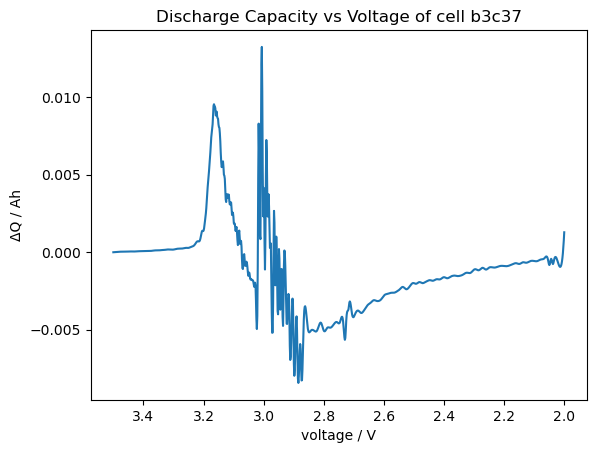

In [45]:
i = 37
c3 = f3[batch3['cycles'][i, 0]]
q10  = f3[c3['Qdlin'][9,  0]][()].ravel()
q100 = f3[c3['Qdlin'][99, 0]][()].ravel()
plt.plot(vd, q100 - q10)
plt.gca().invert_xaxis()
plt.xlabel('voltage / V')
plt.ylabel('ΔQ / Ah') 
plt.title('Discharge Capacity vs Voltage of cell b3c37')
plt.show()

The plot shows that this cell is a bad measurement and would add up to the noise in the model. This one:

- Spikes to +0.013 at 3.2 V. Positive means the cell delivered more capacity at cycle 100 than at cycle 10 — at that voltage, a gain of over 1% of total capacity. Cells don't gain capacity.
- Violent oscillation between 3.1 and 2.8 V. Swings from +0.013 to −0.008 and back, repeatedly, over a few hundredths of a volt (Real electrochem doesn't reverse direction dozens of times in that span)
- A spike at 2.0 V, right at the end.

In [46]:
clean_df = clean_df.drop(index='b3c37')
clean_df.shape

(122, 12)

In [47]:
d = clean_df[['log_var_dQ','cycle_life']]
res = stats.linregress(d.log_var_dQ, np.log10(d.cycle_life))
print(f"n = {len(d)}   r = {res.rvalue:.3f}   r² = {res.rvalue**2:.3f}")

n = 122   r = -0.911   r² = 0.829


In [48]:
clean_df.head()

,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch,log_var_dQ,min_dQ,log_life,z_var_dQ
cell_id,,,,,,,,,,,,
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.077600,0.880536,0.016359,0.019527,1,-4.178878,-0.025179,3.031004,-0.895266
b1c6,4.8C(80%)-4.8C,636.0,635,1.078115,0.880057,0.016926,0.020405,1,-3.768878,-0.037886,2.803457,0.140261
b1c7,4.8C(80%)-4.8C,870.0,869,1.095673,0.881106,0.016241,0.019942,1,-3.813486,-0.038233,2.939519,0.027595
b1c9,5.4C(40%)-3.6C,1054.0,1053,1.084173,0.880928,0.016927,0.020327,1,-4.059384,-0.028724,3.022841,-0.593462
b1c11,5.4C(50%)-3C,788.0,787,1.055643,0.880544,0.016556,0.019324,1,-4.146897,-0.023692,2.896526,-0.814491


In [49]:
print(clean_df.batch.value_counts().sort_index())

batch
1    36
2    43
3    43
Name: count, dtype: int64


# Ex: 1- Train test split done on batch 1 and 2. Validation done on batch 3.
**Ex 1.1- X contains only 1 feature coulmn**

In [50]:
from sklearn.model_selection import train_test_split

dev = clean_df[clean_df.batch.isin([1, 2])].copy()   # 79 cells
sec = clean_df[clean_df.batch == 3].copy()           # 43 cells

X = dev[['log_var_dQ']]
y = dev['log_life']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, X_test.shape)

(55, 1) (24, 1)


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [52]:
model_lm1 = LinearRegression()
model_lm1.fit(X_train,y_train)

y_train_pred = model_lm1.predict(X_train)
y_test_pred = model_lm1.predict(X_test)

r2score_train1 = r2_score(y_train, y_train_pred)
r2score_test1 = r2_score(y_test, y_test_pred)
print('r² score (train):', r2score_train1)
print('r² score (test):', r2score_test1)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print('\nmean_squared_error (train):', mse_train)
print('mean_squared_error (test):', mse_test)

mape_train = mean_absolute_percentage_error(10**y_train, 10**y_train_pred) * 100
print('\nMAPE (train):', mape_train)
mape_test  = mean_absolute_percentage_error(10**y_test,  10**y_test_pred) * 100
print('MAPE (test):', mape_test)

r² score (train): 0.7638726020506432
r² score (test): 0.6739572551112027

mean_squared_error (train): 0.00512832409599817
mean_squared_error (test): 0.004878325556085265

MAPE (train): 13.776314689943122
MAPE (test): 13.653434987776421


In [53]:
compare = pd.DataFrame({
    'actual':    (10**y_test).round(0),
    'predicted': (10**y_test_pred).round(0),
})
compare['error']     = compare.predicted - compare.actual
compare['error_pct'] = (compare.error / compare.actual * 100).round(1)
compare.sort_values('error_pct')

,actual,predicted,error,error_pct
cell_id,,,,
b1c19,788.0,585.0,-203.0,-25.8
b1c38,617.0,483.0,-134.0,-21.7
b1c21,559.0,444.0,-115.0,-20.6
b1c45,599.0,479.0,-120.0,-20.0
b1c32,731.0,601.0,-130.0,-17.8
b1c28,860.0,736.0,-124.0,-14.4
b1c18,691.0,603.0,-88.0,-12.7
b1c41,1051.0,928.0,-123.0,-11.7
b2c12,458.0,430.0,-28.0,-6.1


**Ex 1.2- X contains all 3 feature coulmn**
- min_dQ is not added as it has high colinearity with log_var_dQ

In [54]:
print(dev[['log_var_dQ','min_dQ','Q_initial','IR_initial']].corr().round(2))

            log_var_dQ  min_dQ  Q_initial  IR_initial
log_var_dQ        1.00   -0.94      -0.13        0.23
min_dQ           -0.94    1.00       0.14       -0.17
Q_initial        -0.13    0.14       1.00       -0.35
IR_initial        0.23   -0.17      -0.35        1.00


In [55]:
X2 = dev[['log_var_dQ','Q_initial','IR_initial']]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42)

m2 = LinearRegression().fit(X2_train, y2_train)
print('r² test, 3 features:', r2_score(y2_test, m2.predict(X2_test)))
print('r² test, 1 feature :', r2score_test1)

r² test, 3 features: 0.6650212373059854
r² test, 1 feature : 0.6739572551112027


# Best LR Model for approach 1
**Ex 1.3- X contains all 2 of 3 feature coulmn** 


In [56]:
X3 = dev[['log_var_dQ','Q_initial']]
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.3, random_state=42)

m3 = LinearRegression()
m3.fit(X3_train, y3_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y3_train_pred = m3.predict(X3_train)
y3_test_pred = m3.predict(X3_test)

r2score_train = r2_score(y3_train, y3_train_pred)
r2score_test = r2_score(y3_test, y3_test_pred)
print('r² score (train):', r2score_train)
print('r² score (test):', r2score_test)

mse_train = mean_squared_error(y3_train, y3_train_pred)
mse_test = mean_squared_error(y3_test, y3_test_pred)
print('\nmean_squared_error (train):', mse_train)
print('mean_squared_error (test):', mse_test)

mape_train = mean_absolute_percentage_error(10**y3_train, 10**y3_train_pred) * 100
print('\nMAPE (train):', mape_train)
mape_test  = mean_absolute_percentage_error(10**y3_test,  10**y3_test_pred) * 100
print('MAPE (test):', mape_test)

r² score (train): 0.8175047936937989
r² score (test): 0.7636498112241435

mean_squared_error (train): 0.003963515339736108
mean_squared_error (test): 0.0035363251725907493

MAPE (train): 11.374639315494795
MAPE (test): 11.574429257231472


**Ex 1.4- X contains all 2 of 3 feature coulmn**

In [58]:
X4 = dev[['log_var_dQ','IR_initial']]
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y, test_size=0.3, random_state=42)

m4 = LinearRegression().fit(X4_train, y4_train)
print('r² test, 2 features:', r2_score(y4_test, m4.predict(X4_test)))
print('r² test, 1 feature :', r2score_test1)

r² test, 2 features: 0.5249488689525263
r² test, 1 feature : 0.6739572551112027


### Feature selection: one addition at a time

Each model is linear regression on the development set (batches 1 and 2,
79 cells), split 70/30 with `random_state=42`. The single-feature model is
the reference; each row adds exactly one feature to it.

Experiments| features | r² (test) | change | verdict |
|---|---|---|---|---|
Ex 1.1 | `log_var_dQ` | 0.674 | — | baseline |
Ex 1.2 | `log_var_dQ` + `Q_initial` + `IR_initial` | 0.665 | −0.009 | reject |
Ex 1.3 | `log_var_dQ` + `Q_initial` | **0.764** | +0.090 | keep |
Ex 1.4 | `log_var_dQ` + `IR_initial` | 0.525 | −0.149 | reject |


Only `Q_initial` improves on the single-feature model. Both rejected features
fail for different and identifiable reasons.

**`min_dQ` — redundancy.** Correlation with `log_var_dQ` is −0.94. Both are
computed from the same ΔQ(V) curve: a deeper minimum necessarily means greater
spread. The two columns carry one piece of information, and least squares
splits the coefficient between them arbitrarily. That split is fitted to 55
training cells and does not hold on unseen data.

**`IR_initial` — noise amplification.** Not a lack of variation: its
coefficient of variation is 0.045, five times that of `Q_initial` (0.008).
The fitted coefficients are −0.39 for `log_var_dQ` and −75.42 for
`IR_initial`. Both signs are physically correct, but the magnitudes differ by
a factor of ~200 because the features span very different ranges —
`log_var_dQ` covers about 2.4 units, `IR_initial` about 0.005 Ω. A feature
with that narrow a range requires a large coefficient to influence the output,
which amplifies measurement error by the same factor: a 0.001 Ω error in the
input shifts the prediction by ~19% in cycles. Internal resistance is measured
from a 30 ms current pulse and is not precise to that level.

This is a statement about measurement precision at this sample size, not about
the physical relevance of impedance growth, which is one of the principal
degradation modes in these cells. A differential formulation
(`IR` at cycle 100 − `IR` at cycle 10) may behave better: taking a difference
cancels systematic offset and measures degradation rate rather than initial
condition.

**Note on interpreting small differences.** The test set contains 24 cells, so
a change in r² of roughly 0.02 corresponds to a single cell. Only the
`Q_initial` gain (+0.090) and the `IR_initial` loss (−0.149) are large enough
to be treated as real; the −0.009 row is within noise.

**Current best model:** `log_var_dQ` + `Q_initial`, r² test = 0.764.

# Feature Extraction 2

**Slope of battery degradation between cycle 2 and cycle 100 plotting there discharge capacity for the 99 cycles**

In [59]:
i = 5                   #cell 5 b1c6 as the b1c0- b1c4 removed during cleaning
s = f1[batch1['summary'][i, 0]]
qd = np.asarray(s['QDischarge']).ravel()

cycle_col = np.asarray(s['cycle']).ravel()
cycles = cycle_col[1:100]
capacity = qd[1:100]

print(len(cycles), len(capacity))
print(capacity[:5])
print(capacity[-5:])

99 99
[1.0761266 1.0766531 1.0775996 1.0785232 1.0790976]
[1.0798595 1.079825  1.0797906 1.0797876 1.0797794]


In [60]:

res = stats.linregress(cycles, capacity)
print("slope:", res.slope)
print("r²   :", res.rvalue**2)

slope: 1.1228400742115005e-05
r²   : 0.09479836260513992


In [61]:
slopes = []
for i in range(batch1['summary'].shape[0]):
    s = f1[batch1['summary'][i, 0]]
    qd = np.asarray(s['QDischarge']).ravel()
    if len(qd) < 100: continue
    cyc = np.asarray(s['cycle']).ravel()[1:100]
    res = stats.linregress(cyc, qd[1:100])
    slopes.append({'cell': f'b1c{i}', 'slope': res.slope, 'fit_r2': res.rvalue**2})

sl = pd.DataFrame(slopes)
print(sl.fit_r2.describe())
print("cells with positive slope:", (sl.slope > 0).sum(), "of", len(sl))

count    46.000000
mean      0.202461
std       0.222334
min       0.000036
25%       0.026004
50%       0.147255
75%       0.266299
max       0.920559
Name: fit_r2, dtype: float64
cells with positive slope: 19 of 46


**As seen from above that the slope is positive which means the battery is not losing any capayity by the 100th cycle. Instead it is gaining small capacity because of the breakin process which happens at the beginning in electrochemical cells. So this cannot to taken as a feature for the model to learn**

In [62]:
i = 5
s = f1[batch1['summary'][i, 0]]
ir = np.asarray(s['IR']).ravel()

print("cycle 10 :", ir[9])
print("cycle 100:", ir[99])
print("delta    :", ir[99] - ir[9])
print()
print("cycles 8-12 :", ir[7:12])
print("cycles 98-102:", ir[97:102])

cycle 10 : 0.016248615
cycle 100: 0.016325712
delta    : 7.70969999999982e-05

cycles 8-12 : [0.01625614 0.01625418 0.01624862 0.01622681 0.01624193]
cycles 98-102: [0.01631711 0.01631227 0.01632571 0.01631315 0.01631757]


In [63]:
delta_single = ir[99] - ir[9]
delta_avg    = ir[95:100].mean() - ir[5:10].mean()
print("single point:", delta_single)
print("averaged    :", delta_avg)

single point: 7.70969999999982e-05
averaged    : 5.5809200000003084e-05


In [64]:
def ir_features(f, batch, label):
    rows = []
    for i in range(batch['summary'].shape[0]):
        s = f[batch['summary'][i, 0]]
        ir = np.asarray(s['IR']).ravel()
        if len(ir) < 100:
            rows.append({'cell_id': f'{label}c{i}'})
            continue
        rows.append({
            'cell_id':  f'{label}c{i}',
            'ir_delta': ir[95:100].mean() - ir[5:10].mean(),
        })
    return pd.DataFrame(rows).set_index('cell_id')

ir_feat = pd.concat([
    ir_features(f1, batch1, 'b1'),
    ir_features(f2, batch2, 'b2'),
    ir_features(f3, batch3, 'b3'),
])
print(ir_feat.shape)
print(ir_feat.ir_delta.describe())

(140, 1)
count    140.000000
mean      -0.000011
std        0.000391
min       -0.003986
25%       -0.000071
50%        0.000040
75%        0.000143
max        0.000510
Name: ir_delta, dtype: float64


In [65]:

clean_df = clean_df.join(ir_feat)
print(clean_df.shape)
print(clean_df.ir_delta.isna().sum())

(122, 13)
0


In [ ]:

print("negative:", (clean_df.ir_delta < 0).sum(), "of", len(clean_df))
print(clean_df.ir_delta.desc3ribe())

negative: 53 of 122
count    122.000000
mean      -0.000033
std        0.000411
min       -0.003986
25%       -0.000091
50%        0.000027
75%        0.000141
max        0.000389
Name: ir_delta, dtype: float64


In [67]:

dev = clean_df[clean_df.batch.isin([1,2])]
y = dev['log_life']
for cols in [['log_var_dQ','Q_initial'],
             ['log_var_dQ','Q_initial','ir_delta']]:
    Xa = dev[cols]
    Xtr, Xte, ytr, yte = train_test_split(Xa, y, test_size=0.3, random_state=42)
    m = LinearRegression().fit(Xtr, ytr)
    print(f"test r² {r2_score(yte, m.predict(Xte)):.3f}   {cols}")

test r² 0.764   ['log_var_dQ', 'Q_initial']
test r² 0.607   ['log_var_dQ', 'Q_initial', 'ir_delta']


In [68]:
def dq_stats(f, batch, label):
    rows = []
    for i in range(batch['summary'].shape[0]):
        c = f[batch['cycles'][i, 0]]
        if c['Qdlin'].shape[0] < 100:
            rows.append({'cell_id': f'{label}c{i}'}); continue
        dq = f[c['Qdlin'][99,0]][()].ravel() - f[c['Qdlin'][9,0]][()].ravel()
        rows.append({
            'cell_id':  f'{label}c{i}',
            'dq_skew':  stats.skew(dq),
            'dq_kurt':  stats.kurtosis(dq),
            'dq_mean':  np.log10(np.abs(dq.mean())),
        })
    return pd.DataFrame(rows).set_index('cell_id')

dqs = pd.concat([dq_stats(f1, batch1, 'b1'),
                 dq_stats(f2, batch2, 'b2'),
                 dq_stats(f3, batch3, 'b3')])

clean_df = clean_df.drop(columns=['dq_skew','dq_kurt','dq_mean'], errors='ignore')
clean_df = clean_df.join(dqs)

print(clean_df[['log_var_dQ','dq_skew','dq_kurt','dq_mean']].corr().round(2))

            log_var_dQ  dq_skew  dq_kurt  dq_mean
log_var_dQ        1.00     0.25    -0.28     0.92
dq_skew           0.25     1.00     0.77    -0.02
dq_kurt          -0.28     0.77     1.00    -0.57
dq_mean           0.92    -0.02    -0.57     1.00


In [70]:
dev = clean_df[clean_df.batch.isin([1,2])]
y = dev['log_life']
for cols in [['log_var_dQ','Q_initial'],
             ['log_var_dQ','Q_initial','dq_skew'],
             ['log_var_dQ','Q_initial','dq_kurt']]:
    Xa = dev[cols]
    Xtr, Xte, ytr, yte = train_test_split(Xa, y, test_size=0.3, random_state=42)
    m = LinearRegression().fit(Xtr, ytr)
    print(f"test r² {r2_score(yte, m.predict(Xte)):.3f}   {cols}")

test r² 0.764   ['log_var_dQ', 'Q_initial']
test r² 0.760   ['log_var_dQ', 'Q_initial', 'dq_skew']
test r² 0.760   ['log_var_dQ', 'Q_initial', 'dq_kurt']


In [71]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X3 = dev[['log_var_dQ','Q_initial']]
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.3, random_state=42)

for name, mdl in [('Linear', LinearRegression()),
                  ('Ridge',  Ridge(alpha=1.0)),
                  ('Lasso',  Lasso(alpha=0.001))]:
    pipe = make_pipeline(StandardScaler(), mdl).fit(X3_train, y3_train)
    tr = r2_score(y3_train, pipe.predict(X3_train))
    te = r2_score(y3_test,  pipe.predict(X3_test))
    mape = mean_absolute_percentage_error(10**y3_test, 10**pipe.predict(X3_test))*100
    print(f"{name:8s} train r² {tr:.3f}   test r² {te:.3f}   MAPE {mape:.2f}%")

Linear   train r² 0.818   test r² 0.764   MAPE 11.57%
Ridge    train r² 0.817   test r² 0.763   MAPE 11.63%
Lasso    train r² 0.817   test r² 0.763   MAPE 11.60%


In [72]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

ALL = ['log_var_dQ','Q_initial','min_dQ','IR_initial',
       'ir_delta','dq_skew','dq_kurt','dq_mean']

Xa = dev[ALL]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, y, test_size=0.3, random_state=42)
print(Xa_tr.shape, Xa_te.shape)

(55, 8) (24, 8)


In [73]:
models = {
    'Linear (2 feat)': (LinearRegression(), ['log_var_dQ','Q_initial']),
    'Linear (all)':    (LinearRegression(), ALL),
    'Ridge (all)':     (Ridge(alpha=1.0), ALL),
    'DecisionTree':    (DecisionTreeRegressor(random_state=42), ALL),
    'RandomForest':    (RandomForestRegressor(n_estimators=300, random_state=42), ALL),
    'GradBoost':       (GradientBoostingRegressor(random_state=42), ALL),
}

rows = []
for name, (mdl, cols) in models.items():
    Xtr, Xte = Xa_tr[cols], Xa_te[cols]
    pipe = make_pipeline(StandardScaler(), mdl).fit(Xtr, ya_tr)
    rows.append({
        'model': name,
        'n_feat': len(cols),
        'train_r2': r2_score(ya_tr, pipe.predict(Xtr)),
        'test_r2':  r2_score(ya_te, pipe.predict(Xte)),
        'test_MAPE': mean_absolute_percentage_error(
                        10**ya_te, 10**pipe.predict(Xte))*100,
    })

res = pd.DataFrame(rows).round(3)
res['gap'] = (res.train_r2 - res.test_r2).round(3)
print(res.to_string(index=False))

          model  n_feat  train_r2  test_r2  test_MAPE   gap
Linear (2 feat)       2     0.818    0.764     11.574 0.054
   Linear (all)       8     0.890    0.696     11.173 0.194
    Ridge (all)       8     0.865    0.621     11.703 0.244
   DecisionTree       8     1.000    0.743     11.320 0.257
   RandomForest       8     0.968    0.827      8.439 0.141
      GradBoost       8     1.000    0.842      8.814 0.158


In [74]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, (mdl, cols) in models.items():
    pipe = make_pipeline(StandardScaler(), mdl)
    s = cross_val_score(pipe, dev[cols], y, cv=kf, scoring='r2')
    print(f"{name:18s} CV r² {s.mean():.3f} ± {s.std():.3f}")

Linear (2 feat)    CV r² 0.746 ± 0.083
Linear (all)       CV r² 0.699 ± 0.121
Ridge (all)        CV r² 0.664 ± 0.210
DecisionTree       CV r² 0.693 ± 0.125
RandomForest       CV r² 0.764 ± 0.170
GradBoost          CV r² 0.774 ± 0.138


In [75]:
feature_sets = {
    '2 feat':  ['log_var_dQ','Q_initial'],
    '1 feat':  ['log_var_dQ'],
    '4 feat':  ['log_var_dQ','Q_initial','dq_skew','dq_kurt'],
    'all 8':   ALL,
}

for label, cols in feature_sets.items():
    pipe = make_pipeline(StandardScaler(), GradientBoostingRegressor(random_state=42))
    s = cross_val_score(pipe, dev[cols], y, cv=kf, scoring='r2')
    print(f"GradBoost {label:8s} CV r² {s.mean():.3f} ± {s.std():.3f}")

GradBoost 2 feat   CV r² 0.794 ± 0.042
GradBoost 1 feat   CV r² 0.687 ± 0.122
GradBoost 4 feat   CV r² 0.777 ± 0.077
GradBoost all 8    CV r² 0.774 ± 0.138


In [76]:
for label, cols in feature_sets.items():
    pipe = make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=300, random_state=42))
    s = cross_val_score(pipe, dev[cols], y, cv=kf, scoring='r2')
    print(f"RandomForest {label:8s} CV r² {s.mean():.3f} ± {s.std():.3f}")

RandomForest 2 feat   CV r² 0.796 ± 0.062
RandomForest 1 feat   CV r² 0.706 ± 0.111
RandomForest 4 feat   CV r² 0.793 ± 0.083
RandomForest all 8    CV r² 0.764 ± 0.170


In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'gradientboostingregressor__n_estimators': [50, 100, 200],
    'gradientboostingregressor__max_depth': [1, 2, 3],
    'gradientboostingregressor__learning_rate': [0.01, 0.05, 0.1],
    'gradientboostingregressor__min_samples_leaf': [1, 3, 5],
}

pipe = make_pipeline(StandardScaler(), GradientBoostingRegressor(random_state=42))
gs = GridSearchCV(pipe, param_grid, cv=kf, scoring='r2', n_jobs=-1)
gs.fit(dev[['log_var_dQ','Q_initial']], y)

print("best CV r²:", round(gs.best_score_, 3))
print(gs.best_params_)

best CV r²: 0.799
{'gradientboostingregressor__learning_rate': 0.1, 'gradientboostingregressor__max_depth': 3, 'gradientboostingregressor__min_samples_leaf': 1, 'gradientboostingregressor__n_estimators': 50}


In [78]:
X_sec = sec[['log_var_dQ','Q_initial']]
y_sec = sec['log_life']

X2 = dev[['log_var_dQ','Q_initial']]

for name, mdl in [('Linear', LinearRegression()),
                  ('GradBoost', GradientBoostingRegressor(random_state=42))]:
    pipe = make_pipeline(StandardScaler(), mdl).fit(X2, y)
    pred = pipe.predict(X_sec)
    print(f"{name:10s} secondary r² {r2_score(y_sec, pred):.3f}   "
          f"MAPE {mean_absolute_percentage_error(10**y_sec, 10**pred)*100:.2f}%")

Linear     secondary r² 0.499   MAPE 12.91%
GradBoost  secondary r² -0.319   MAPE 19.41%


In [79]:
print(dev[['log_var_dQ','Q_initial','log_life']].describe().T[['mean','std','min','max']].round(3))
print(sec[['log_var_dQ','Q_initial','log_life']].describe().T[['mean','std','min','max']].round(3))

             mean    std    min    max
log_var_dQ -3.618  0.283 -4.179 -2.727
Q_initial   1.075  0.009  1.043  1.096
log_life    2.768  0.142  2.170  3.031
             mean    std    min    max
log_var_dQ -4.173  0.260 -4.779 -3.452
Q_initial   1.065  0.007  1.047  1.075
log_life    3.006  0.118  2.733  3.287


In [80]:
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(dev[['log_var_dQ']], y)
pred = pipe.predict(sec[['log_var_dQ']])
print(f"1-feature linear, secondary: r² {r2_score(y_sec,pred):.3f}  MAPE {mean_absolute_percentage_error(10**y_sec,10**pred)*100:.2f}%")

1-feature linear, secondary: r² 0.585  MAPE 13.24%


In [81]:
pipe = make_pipeline(StandardScaler(),
                     RandomForestRegressor(n_estimators=300, random_state=42)).fit(X2, y)
pred = pipe.predict(X_sec)
print(f"RF 2-feature, secondary: r² {r2_score(y_sec, pred):.3f}  "
      f"MAPE {mean_absolute_percentage_error(10**y_sec, 10**pred)*100:.2f}%")

RF 2-feature, secondary: r² -0.426  MAPE 19.28%


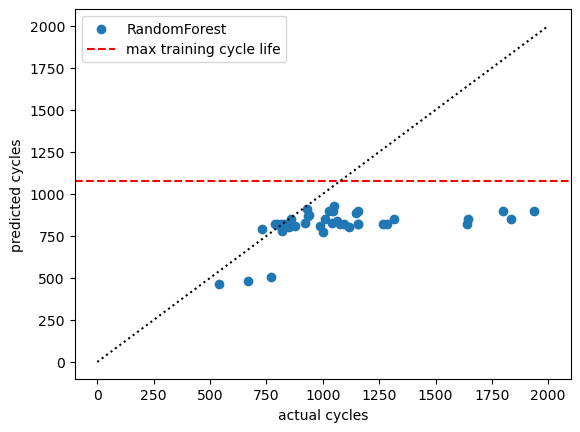

In [82]:
plt.scatter(10**y_sec, 10**pred, label='RandomForest')
plt.axhline(10**y.max(), ls='--', c='r', label='max training cycle life')
plt.plot([0,2000],[0,2000],'k:')
plt.xlabel('actual cycles'); plt.ylabel('predicted cycles'); plt.legend(); plt.show()

# Ex-2 Split train test data by from all 3 batches

In [83]:
all_dev = clean_df.copy()
X_all = all_dev[['log_var_dQ','Q_initial']]
y_all = all_dev['log_life']

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
print(Xa_tr.shape, Xa_te.shape)

for name, mdl in [('Linear', LinearRegression()),
                  ('RandomForest', RandomForestRegressor(n_estimators=300, random_state=42)),
                  ('GradBoost', GradientBoostingRegressor(random_state=42))]:
    pipe = make_pipeline(StandardScaler(), mdl).fit(Xa_tr, ya_tr)
    pred = pipe.predict(Xa_te)
    print(f"{name:14s} test r² {r2_score(ya_te, pred):.3f}  "
          f"MAPE {mean_absolute_percentage_error(10**ya_te, 10**pred)*100:.2f}%")

(85, 2) (37, 2)
Linear         test r² 0.822  MAPE 11.81%
RandomForest   test r² 0.787  MAPE 12.62%
GradBoost      test r² 0.709  MAPE 12.54%


In [84]:
kf_all = KFold(n_splits=5, shuffle=True, random_state=42)

for label, cols in feature_sets.items():
    for name, mdl in [('Linear', LinearRegression()),
                      ('RF', RandomForestRegressor(n_estimators=300, random_state=42)),
                      ('GB', GradientBoostingRegressor(random_state=42))]:
        s = cross_val_score(make_pipeline(StandardScaler(), mdl),
                            all_dev[cols], y_all, cv=kf_all, scoring='r2')
        print(f"{name:7s} {label:8s} CV r² {s.mean():.3f} ± {s.std():.3f}")
    print()

Linear  2 feat   CV r² 0.838 ± 0.040
RF      2 feat   CV r² 0.816 ± 0.058
GB      2 feat   CV r² 0.797 ± 0.112

Linear  1 feat   CV r² 0.810 ± 0.027
RF      1 feat   CV r² 0.795 ± 0.037
GB      1 feat   CV r² 0.775 ± 0.072

Linear  4 feat   CV r² 0.833 ± 0.040
RF      4 feat   CV r² 0.817 ± 0.039
GB      4 feat   CV r² 0.819 ± 0.054

Linear  all 8    CV r² 0.832 ± 0.038
RF      all 8    CV r² 0.832 ± 0.042
GB      all 8    CV r² 0.849 ± 0.045



In [85]:
for seed in [0, 7, 123]:
    kf2 = KFold(n_splits=5, shuffle=True, random_state=seed)
    s = cross_val_score(make_pipeline(StandardScaler(), GradientBoostingRegressor(random_state=42)),
                        all_dev[ALL], y_all, cv=kf2, scoring='r2')
    print(f"seed {seed}: GB all-8 CV r² {s.mean():.3f} ± {s.std():.3f}")

seed 0: GB all-8 CV r² 0.821 ± 0.044
seed 7: GB all-8 CV r² 0.850 ± 0.016
seed 123: GB all-8 CV r² 0.827 ± 0.052


In [86]:
from sklearn.model_selection import cross_validate

rows = []
for label, cols in feature_sets.items():
    for name, mdl in [('Linear', LinearRegression()),
                      ('RF', RandomForestRegressor(n_estimators=300, random_state=42)),
                      ('GB', GradientBoostingRegressor(random_state=42))]:
        cv = cross_validate(make_pipeline(StandardScaler(), mdl),
                            all_dev[cols], y_all, cv=kf_all,
                            scoring='r2', return_train_score=True)
        rows.append({
            'model': name,
            'features': label,
            'train_r2': cv['train_score'].mean(),
            'test_r2':  cv['test_score'].mean(),
            'test_std': cv['test_score'].std(),
        })

res = pd.DataFrame(rows).round(3)
res['gap'] = (res.train_r2 - res.test_r2).round(3)
print(res.sort_values('test_r2', ascending=False).to_string(index=False))


 model features  train_r2  test_r2  test_std   gap
    GB    all 8     0.998    0.849     0.045 0.149
Linear   2 feat     0.859    0.838     0.040 0.021
Linear   4 feat     0.862    0.833     0.040 0.029
Linear    all 8     0.900    0.832     0.038 0.068
    RF    all 8     0.980    0.832     0.042 0.148
    GB   4 feat     0.996    0.819     0.054 0.177
    RF   4 feat     0.976    0.817     0.039 0.159
    RF   2 feat     0.978    0.816     0.058 0.162
Linear   1 feat     0.830    0.810     0.027 0.020
    GB   2 feat     0.992    0.797     0.112 0.195
    RF   1 feat     0.974    0.795     0.037 0.179
    GB   1 feat     0.980    0.775     0.072 0.205


# Neural Network approach

In [88]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 2.6 MB/s eta 0:02:18
   ---------------------------------------- 1.0/351.2 MB 2.2 MB/s eta 0:02:37
   ---------------------------------------- 1.6/351.2 MB 2.2 MB/s eta 0:02:42
   ---------------------------------------- 1.8/351.2 MB 2.1 MB/s eta 0:02:45
   ---------------------------------------- 2.4/351.2 MB 2.0 MB/s eta 0:02:56
   ---------------------------------------- 2.4/351.2 MB 2.0 MB/s eta 0:02:56
   ---------------------------------------- 2.6/351.2 MB 1.7 MB/s eta 0:03:23
   ---------------------------------------- 2.9/351.2 MB 1.6 MB/s eta 0:03:38
   ---------------------------------------- 3.1/351.2 MB 1.6 MB/s eta 0:03:36
   ---------------------------------------- 3.4/351.2 MB 1.6 MB/s eta 0:03:42
   ---------------------------------------- 3.7/351.2 MB 1.6 MB/s eta 0:03:43


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [89]:
import tensorflow as tf
from tensorflow import keras

FEATS = ['log_var_dQ', 'Q_initial']

X_tr, X_te, y_tr, y_te = train_test_split(
    all_dev[FEATS], y_all, test_size=0.3, random_state=42)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

print(X_tr_s.shape, X_te_s.shape)

(85, 2) (37, 2)


In [92]:
tf.random.set_seed(42)
model = keras.Sequential([
    keras.layers.Input(shape=(len(FEATS),)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8,  activation='relu'),
    keras.layers.Dense(1)
])
model.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [94]:
es = keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)
h = model.fit(X_tr_s, y_tr, validation_data=(X_te_s, y_te),
              epochs=500, batch_size=16, callbacks=[es], verbose=0)

print("stopped at epoch:", len(h.history['loss']))
for name, Xs, ys in [('train', X_tr_s, y_tr), ('test', X_te_s, y_te)]:
    pred = model.predict(Xs, verbose=0).ravel()
    print(f"{name:6s} r² {r2_score(ys, pred):.3f}  MAPE {mean_absolute_percentage_error(10**ys, 10**pred)*100:.2f}%")

stopped at epoch: 51
train  r² 0.815  MAPE 13.39%
test   r² 0.779  MAPE 13.17%


In [95]:
for seed in [0, 7, 42]:
    tf.random.set_seed(seed)
    m = keras.Sequential([keras.layers.Input(shape=(len(FEATS),)),
                          keras.layers.Dense(16, activation='relu'),
                          keras.layers.Dense(8, activation='relu'),
                          keras.layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
    m.fit(X_tr_s, y_tr, validation_data=(X_te_s, y_te), epochs=500,
          batch_size=16, callbacks=[keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)],
          verbose=0)
    p = m.predict(X_te_s, verbose=0).ravel()
    print(f"seed {seed}: test r² {r2_score(y_te,p):.3f}  MAPE {mean_absolute_percentage_error(10**y_te,10**p)*100:.2f}%")

seed 0: test r² 0.814  MAPE 11.49%
seed 7: test r² 0.835  MAPE 10.68%
seed 42: test r² 0.812  MAPE 11.59%


In [98]:

pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(dev[FEATS_2], y)

resid = y - pipe.predict(dev[FEATS_2])
s = resid.std()
print(f"residual std (log-life): {s:.4f}")
print(f"≈ ±{(10**(1.96*s) - 1)*100:.0f}% in cycles")

residual std (log-life): 0.0622
≈ ±32% in cycles


In [99]:
pred_log = pipe.predict(sec[FEATS_2])
lo, hi = pred_log - 1.96*s, pred_log + 1.96*s
inside = ((y_sec >= lo) & (y_sec <= hi)).mean()
print(f"batch 3 cells inside 95% interval: {inside*100:.0f}%")

batch 3 cells inside 95% interval: 84%


In [100]:
outside = (y_sec < lo) | (y_sec > hi)
print(f"{outside.sum()} of {len(sec)} outside")
print(pd.DataFrame({
    'actual': (10**y_sec[outside]).round(0),
    'predicted': (10**pred_log[outside]).round(0),
    'log_var_dQ': sec.log_var_dQ[outside].round(3),
}))

7 of 43 outside
         actual  predicted  log_var_dQ
cell_id                               
b3c6      667.0      477.0      -3.526
b3c7     1836.0     1264.0      -4.489
b3c22    1002.0      744.0      -4.047
b3c28     541.0      402.0      -3.452
b3c38    1935.0     1125.0      -4.342
b3c42    1642.0     1096.0      -4.346
b3c45    1801.0     1327.0      -4.521


In [101]:
for z in [1.96, 2.5, 3.0]:
    inside = ((y_sec >= pred_log - z*s) & (y_sec <= pred_log + z*s)).mean()
    print(f"±{z}σ = ±{(10**(z*s)-1)*100:.0f}%  →  covers {inside*100:.0f}% of batch 3")

±1.96σ = ±32%  →  covers 84% of batch 3
±2.5σ = ±43%  →  covers 93% of batch 3
±3.0σ = ±54%  →  covers 98% of batch 3


In [102]:
import re

def parse_policy(p):
    p = str(p).replace('-newstructure', '')
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p)
    if not m:
        return pd.Series({'c1': np.nan, 'soc_switch': np.nan, 'c2': np.nan})
    return pd.Series({'c1': float(m.group(1)),
                      'soc_switch': float(m.group(2)),
                      'c2': float(m.group(3))})

pol = all_dev.policy.apply(parse_policy)
print("failed to parse:", pol.c1.isna().sum(), "of", len(pol))
print(pol.describe().round(2))

failed to parse: 1 of 122
           c1  soc_switch      c2
count  121.00      121.00  121.00
mean     5.33       43.61    4.25
std      1.14       22.40    0.83
min      1.00        2.00    3.00
25%      4.80       25.00    3.60
50%      5.40       40.00    4.25
75%      5.90       60.00    4.80
max      8.00       80.00    6.00


In [104]:
pol['c_avg']    = (pol.c1*pol.soc_switch + pol.c2*(80 - pol.soc_switch)) / 80
pol['c_max']    = pol[['c1','c2']].max(axis=1)
pol['c_step']   = pol.c1 - pol.c2
pol['charge_t'] = pol.soc_switch/pol.c1 + (80 - pol.soc_switch)/pol.c2

all_dev1 = all_dev.join(pol)
print(list(pol.columns))

['c1', 'soc_switch', 'c2', 'c_avg', 'c_max', 'c_step', 'charge_t']


In [105]:
for cols in [['log_var_dQ','Q_initial'],
             ['log_var_dQ','Q_initial','c_max'],
             ['log_var_dQ','Q_initial','c_avg','c_max','soc_switch']]:
    d = all_dev1[cols + ['log_life']].dropna()
    s = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                        d[cols], d['log_life'], cv=kf_all, scoring='r2')
    print(f"CV r² {s.mean():.3f} ± {s.std():.3f}   n={len(d)}   {cols}")

CV r² 0.838 ± 0.040   n=122   ['log_var_dQ', 'Q_initial']
CV r² 0.835 ± 0.028   n=121   ['log_var_dQ', 'Q_initial', 'c_max']
CV r² 0.846 ± 0.025   n=121   ['log_var_dQ', 'Q_initial', 'c_avg', 'c_max', 'soc_switch']


In [106]:
d = all_dev1[['c1','soc_switch','c2','c_avg','c_max','charge_t','log_life']].dropna()
s = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                    d[['c1','soc_switch','c2','c_avg','c_max','charge_t']],
                    d['log_life'], cv=kf_all, scoring='r2')
print(f"policy only: CV r² {s.mean():.3f} ± {s.std():.3f}")

policy only: CV r² 0.240 ± 0.190


In [107]:
FEATS_FINAL = ['log_var_dQ', 'Q_initial', 'c_avg', 'c_max', 'soc_switch']

model_df = all_dev1[FEATS_FINAL + ['log_life', 'cycle_life', 'batch', 'policy']].dropna()
print(model_df.shape)
print(model_df.batch.value_counts().sort_index())

(121, 9)
batch
1    36
2    42
3    43
Name: count, dtype: int64


In [108]:
for name, mdl in [('Linear', LinearRegression()),
                  ('RF',     RandomForestRegressor(n_estimators=300, random_state=42)),
                  ('GB',     GradientBoostingRegressor(random_state=42))]:
    cv = cross_validate(make_pipeline(StandardScaler(), mdl),
                        model_df[FEATS_FINAL], model_df.log_life,
                        cv=kf_all, scoring='r2', return_train_score=True)
    tr, te = cv['train_score'].mean(), cv['test_score'].mean()
    print(f"{name:7s} train {tr:.3f}  test {te:.3f} ± {cv['test_score'].std():.3f}  gap {tr-te:.3f}")

Linear  train 0.881  test 0.846 ± 0.025  gap 0.035
RF      train 0.978  test 0.839 ± 0.037  gap 0.138
GB      train 0.995  test 0.813 ± 0.042  gap 0.182


In [109]:
dev_f = model_df[model_df.batch.isin([1,2])]
sec_f = model_df[model_df.batch == 3]

for name, mdl in [('Linear', LinearRegression()),
                  ('RF',     RandomForestRegressor(n_estimators=300, random_state=42)),
                  ('GB',     GradientBoostingRegressor(random_state=42))]:
    p = make_pipeline(StandardScaler(), mdl).fit(dev_f[FEATS_FINAL], dev_f.log_life)
    pred = p.predict(sec_f[FEATS_FINAL])
    print(f"{name:7s} secondary r² {r2_score(sec_f.log_life, pred):.3f}  "
          f"MAPE {mean_absolute_percentage_error(10**sec_f.log_life, 10**pred)*100:.2f}%")

Linear  secondary r² 0.481  MAPE 13.32%
RF      secondary r² -0.854  MAPE 22.73%
GB      secondary r² -0.878  MAPE 23.37%


In [123]:
combos = {
    'log_var_dQ only':                    ['log_var_dQ'],
    'policy only':                        ['c1','soc_switch','c2','c_avg','c_max','charge_t'],
    'log_var_dQ + policy':                ['log_var_dQ','c1','soc_switch','c2','c_avg','c_max','charge_t'],
    'log_var_dQ + Q_initial':             ['log_var_dQ','Q_initial'],
    'log_var_dQ + policy + Q_initial':    ['log_var_dQ','c1','soc_switch','c2','c_avg','c_max','charge_t','Q_initial'],

}

for label, cols in combos.items():
    d = all_dev1[cols + ['log_life']].dropna()
    cv = cross_validate(make_pipeline(StandardScaler(), LinearRegression()),
                        d[cols], d.log_life, cv=kf_all,
                        scoring='r2', return_train_score=True)
    tr, te = cv['train_score'].mean(), cv['test_score'].mean()
    print(f"{label:<30}  train {tr:>5.3f}  test {te:>5.3f} ± {cv['test_score'].std():>5.3f}  n={len(d)}")

log_var_dQ only                 train 0.830  test 0.810 ± 0.027  n=122
policy only                     train 0.354  test 0.240 ± 0.190  n=121
log_var_dQ + policy             train 0.867  test 0.828 ± 0.014  n=121
log_var_dQ + Q_initial          train 0.859  test 0.838 ± 0.040  n=122
log_var_dQ + policy + Q_initial  train 0.894  test 0.859 ± 0.017  n=121


In [122]:
d.head()

,log_var_dQ,c1,soc_switch,c2,c_avg,c_max,charge_t,Q_initial,log_life
cell_id,,,,,,,,,
b1c5,-4.178878,4.4,80.0,4.4,4.4,4.4,18.181818,1.077600,3.031004
b1c6,-3.768878,4.8,80.0,4.8,4.8,4.8,16.666667,1.078115,2.803457
b1c7,-3.813486,4.8,80.0,4.8,4.8,4.8,16.666667,1.095673,2.939519
b1c9,-4.059384,5.4,40.0,3.6,4.5,5.4,18.518519,1.084173,3.022841
b1c11,-4.146897,5.4,50.0,3.0,4.5,5.4,19.259259,1.055643,2.896526


In [112]:
FEATS_7 = ['log_var_dQ','c1','soc_switch','c2','c_avg','c_max','charge_t','Q_initial']
d = all_dev1[FEATS_7 + ['log_life','batch']].dropna()
dv, sc = d[d.batch.isin([1,2])], d[d.batch==3]

p = make_pipeline(StandardScaler(), LinearRegression()).fit(dv[FEATS_7], dv.log_life)
pred = p.predict(sc[FEATS_7])
print(f"secondary r² {r2_score(sc.log_life, pred):.3f}  "
      f"MAPE {mean_absolute_percentage_error(10**sc.log_life, 10**pred)*100:.2f}%")

secondary r² 0.557  MAPE 12.74%


In [113]:
print(dict(zip(FEATS_7, p[-1].coef_.round(3))))

{'log_var_dQ': np.float64(-0.124), 'c1': np.float64(-0.011), 'soc_switch': np.float64(0.023), 'c2': np.float64(0.009), 'c_avg': np.float64(0.019), 'c_max': np.float64(0.026), 'charge_t': np.float64(0.02), 'Q_initial': np.float64(0.031)}


In [125]:
FEATS_8 = ['log_var_dQ','Q_initial','c1','soc_switch','c2','c_avg','c_max','charge_t']
d8 = all_dev1[FEATS_8 + ['log_life','batch']].dropna()
dv8, sc8 = d8[d8.batch.isin([1,2])], d8[d8.batch == 3]

p8 = make_pipeline(StandardScaler(), LinearRegression()).fit(dv8[FEATS_8], dv8.log_life)

resid = dv8.log_life - p8.predict(dv8[FEATS_8])
s8 = resid.std()
print(f"residual std: {s8:.4f}   →  ±{(10**(1.96*s8)-1)*100:.0f}% in cycles")
print(f"(2-feature was 0.0622  →  ±32%)")

pred_log = p8.predict(sc8[FEATS_8])
for z in [1.96, 2.5, 3.0]:
    inside = ((sc8.log_life >= pred_log - z*s8) & (sc8.log_life <= pred_log + z*s8)).mean()
    print(f"±{z}σ = ±{(10**(z*s8)-1)*100:.0f}%  →  covers {inside*100:.0f}% of batch 3")

residual std: 0.0532   →  ±27% in cycles
(2-feature was 0.0622  →  ±32%)
±1.96σ = ±27%  →  covers 84% of batch 3
±2.5σ = ±36%  →  covers 93% of batch 3
±3.0σ = ±44%  →  covers 98% of batch 3


In [124]:
import pickle
from pathlib import Path
import shutil, sklearn

Path('models').mkdir(exist_ok=True)

# clear the old ones so nothing stale survives
for f in Path('models').glob('*.pkl'):
    f.unlink()

FEATS_8 = ['log_var_dQ','Q_initial','c1','soc_switch','c2','c_avg','c_max','charge_t']
FEATS_2 = ['log_var_dQ','Q_initial']
FEATS_1 = ['log_var_dQ']

d8 = all_dev1[FEATS_8 + ['log_life']].dropna()

to_save = {
    'LR_model_8Feat_with_policy(best)': (LinearRegression(),                                       FEATS_8),
    'LR_model_2Feat':       (LinearRegression(),                                       FEATS_2),
    'LR_model_1Feat':       (LinearRegression(),                                       FEATS_1),
    'GB_model_8Feat':       (GradientBoostingRegressor(random_state=42),               FEATS_8),
    'RF_model_8Feat':       (RandomForestRegressor(n_estimators=300, random_state=42), FEATS_8),
}

for name, (mdl, cols) in to_save.items():
    dd = all_dev1[cols + ['log_life']].dropna()
    pipe = make_pipeline(StandardScaler(), mdl).fit(dd[cols], dd.log_life)
    with open(f'models/{name}.pkl', 'wb') as f:
        pickle.dump({'pipeline': pipe,
                     'features': cols,
                     'target': 'log_life',
                     'n_train': len(dd),
                     'sklearn_version': sklearn.__version__}, f)
    print(f"saved {name}.pkl  ({len(cols)} features, n={len(dd)})")

saved LR_model_8Feat_with_policy(best).pkl  (8 features, n=121)
saved LR_model_2Feat.pkl  (2 features, n=122)
saved LR_model_1Feat.pkl  (1 features, n=122)
saved GB_model_8Feat.pkl  (8 features, n=121)
saved RF_model_8Feat.pkl  (8 features, n=121)


In [126]:
app_df = all_dev1.dropna(subset=FEATS_8)
app_df.to_parquet('models/app_data.parquet')
print(app_df.shape, "\n", app_df.columns.tolist())

(121, 23) 
 ['policy', 'cycle_life', 'n_cycles', 'Q_initial', 'Q_last', 'IR_initial', 'IR_last', 'batch', 'log_var_dQ', 'min_dQ', 'log_life', 'z_var_dQ', 'ir_delta', 'dq_skew', 'dq_kurt', 'dq_mean', 'c1', 'soc_switch', 'c2', 'c_avg', 'c_max', 'c_step', 'charge_t']


In [127]:
dq_store = {}
for f, batch, lab in [(f1, batch1, 'b1'), (f2, batch2, 'b2'), (f3, batch3, 'b3')]:
    for i in range(batch['summary'].shape[0]):
        cid = f'{lab}c{i}'
        if cid not in app_df.index:
            continue
        c = f[batch['cycles'][i, 0]]
        dq = f[c['Qdlin'][99, 0]][()].ravel() - f[c['Qdlin'][9, 0]][()].ravel()
        dq_store[cid] = dq.astype('float32')

np.savez_compressed('models/dq_curves.npz', **dq_store)
np.save('models/vdlin.npy', f1[batch1['Vdlin'][0, 0]][()].ravel())
print("curves saved:", len(dq_store), "of", len(app_df))

curves saved: 121 of 121


In [128]:
fade_store = {}
for f, batch, lab in [(f1, batch1, 'b1'), (f2, batch2, 'b2'), (f3, batch3, 'b3')]:
    for i in range(batch['summary'].shape[0]):
        cid = f'{lab}c{i}'
        if cid not in app_df.index:
            continue
        s = f[batch['summary'][i, 0]]
        fade_store[cid] = np.asarray(s['QDischarge']).ravel().astype('float32')

np.savez_compressed('models/fade_curves.npz', **fade_store)
print("fade curves saved:", len(fade_store))

fade curves saved: 121


In [129]:
from pathlib import Path
for p in sorted(Path('models').glob('*')):
    print(f"{p.name:32s} {p.stat().st_size/1e6:8.2f} MB")

app_data.parquet                     0.03 MB
dq_curves.npz                        0.47 MB
fade_curves.npz                      0.32 MB
GB_model_8Feat.pkl                   0.13 MB
LR_model_1Feat.pkl                   0.00 MB
LR_model_2Feat.pkl                   0.00 MB
LR_model_8Feat_with_policy(best).pkl     0.00 MB
RF_model_8Feat.pkl                   3.34 MB
vdlin.npy                            0.01 MB
